# Clusterización: Métricas de Distancia

* Lo que mencionas —Euclidiana, Manhattan y Chebyshev— no son algoritmos de clustering como K-Means, DBSCAN o Affinity Propagation, sino métricas de distancia que los algoritmos de clustering usan para medir qué tan “parecidos” o “lejanos” están dos puntos.
* ¿Por qué son importantes en Clustering?
  - Los algoritmos de clustering (como K-Means, DBSCAN, Hierarchical Clustering) necesitan una forma de medir qué tan cerca o lejos están los puntos. Esa medida depende de la métrica de distancia elegida:
  - `Euclidiana` → clusters circulares/esféricos.
  - `Manhattan` → clusters en forma de rombos/cuadrículas.
  - `Chebyshev` → clusters cuadrados que dependen de la mayor diferencia en un atributo.
* La elección de la métrica puede cambiar radicalmente los clusters que se obtienen.

### Distancia Euclidiana

* ¿Cuándo es mejor usarla?
  - Datos continuos y cuantitativos
  - Funciona muy bien cuando tus variables son numéricas y tienen sentido geométrico.
  - Ejemplo: edad, ingresos, altura, peso.
  - `Clusters esféricos o circulares`.
  - `K-Means con distancia Euclidiana tiende a formar clusters de forma “redonda”`.
  - Si los datos realmente se agrupan en torno a un centro con esa forma, es ideal.
  - `Escala homogénea entre variables`
  - `Se recomienda cuando todas las variables están en la misma escala o después de aplicar escalado/normalización (ej. MinMaxScaler, StandardScaler)`.
  - De lo contrario, una variable con valores muy grandes puede dominar la distancia.
  - `Espacios donde “la ruta más corta” tiene sentido`.
  - Ejemplo: coordenadas geográficas en un plano (x, y), colores en RGB normalizado, etc.

* Cuándo no es ideal
  - Si los datos tienen mucha dispersión en una dimensión (una variable con rango 0–10, otra con rango 0–10,000).
  - Si las relaciones son más tipo cuadrícula o conteos (ahí sería mejor Manhattan).
  - Si los clusters no son esféricos (ej. datos alargados en forma de elipse).

* ***Ejemplo Ilustrattivo***

![Euclidiana.png](Euclidiana.png)
![FormulaEuclidiana.png](FormulaEuclidiana.png)

### Distancia Cherisev

* Mide la mayor diferencia en cualquiera de las dimensiones.
* Imagina un tablero de ajedrez: la distancia Chebyshev entre dos casillas es el número de movimientos mínimos que necesitaría un rey para ir de una a otra (porque el rey se mueve en cualquier dirección una casilla a la vez).
* ¿Cuándo es mejor usarla?
  - `Cuando te interesa el “peor caso” entre atributos`.
  - Ejemplo: en control de calidad, un producto puede fallar si algún atributo excede un límite, no importa que los demás estén bien.
  - La Chebyshev `detecta eso porque se fija en la máxima diferencia`.
  - En problemas de logística y ajedrez (o cuadrículas con movimientos diagonales permitidos)
  - Si te mueves en un plano donde puedes ir en diagonal y horizontal/vertical, esta es la métrica más realista.
  - Clusters de forma cuadrada
  - Mientras la Euclidiana genera clusters circulares y Manhattan genera rombos, Chebyshev produce clusters cuadrados (basados en la máxima diferencia de coordenadas).

* Cuándo no es ideal
  - Si esperas clusters “redondeados” (ahí es mejor Euclidiana).
  - Si las dimensiones tienen significados distintos y no todas son igual de críticas.
  - Puede ser demasiado rígida: un valor atípico en una sola dimensión puede dominar toda la medida.

![Chebyshev.png](Chebyshev.png)
![FormulaChebyshev.png](FormulaChebushev.png)

### Distancia Manhattan

* Es la suma de las diferencias absolutas entre coordenadas.
* Distancia taxicab (porque mide la distancia que recorrería un taxi en una ciudad con calles en cuadrícula).
* L1 norm en álgebra lineal.

* ¿Cuándo es mejor usarla?
  - Datos con movimiento restringido a cuadrículas
  - `Ejemplo: logística urbana, donde los vehículos solo se mueven por calles (horizontal/vertical)`.
  - Manhattan es más realista que Euclidiana en este contexto.
  - `Clusters en forma de rombo`
  - Mientras Euclidiana produce clusters circulares y Chebyshev cuadrados, Manhattan produce clusters en forma de diamante.
  - `Cuando las variables no son continuas, sino discretas o categóricas ordinales`
  - `Ejemplo: número de visitas al sitio web, número de compras, etc.`
  - Más robusta ante outliers que la Euclidiana.
  - Porque no eleva las diferencias al cuadrado (como sí pasa en Euclidiana).

* Cuándo no es ideal
  - Si los datos tienen una geometría circular o radial, Euclidiana se ajusta mejor.
  - Si todas las dimensiones no tienen la misma escala y no normalizas primero, una dimensión puede dominar.

![Manhattan.png](Manhattan.png)
![FormulaManhattan.png](FormulaManhattan.png)

### Contexto

* Estos datos están escalados.
* Representa el precio de las casas en base a los años
* `datos` es un array numpy
* Por ahora solo mostramos los primeros 5 datos

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
datos = np.loadtxt("venta_propiedades.csv", delimiter=",")
datos[0:5:1]

array([[ 1.698042,  6.194126],
       [ 1.028309, 10.013562],
       [ 1.498665, 17.396522],
       [ 0.98841 , 23.138509],
       [ 1.04231 , 23.670459]])

### Graficado de los datos

* `(x=datos[:, 0]` y `datos[:, 1]` al ser `datos` una lista de lista, accedemos a la primera columna y luego a la segunda de cada elemento.
* `np.linspace(0, 1, datos.shape[0])` → genera un arreglo de valores igualmente espaciados entre 0 y 1, con tantos elementos como puntos tengas.
* Cuando lo pasas a `plt.scatter(..., c=c)`, cada punto `se colorea con un valor distinto de esa escala`. Matplotlib interpreta esos valores como un mapa de colores continuo (por defecto, colormap "viridis" o el que le indiques con cmap=).

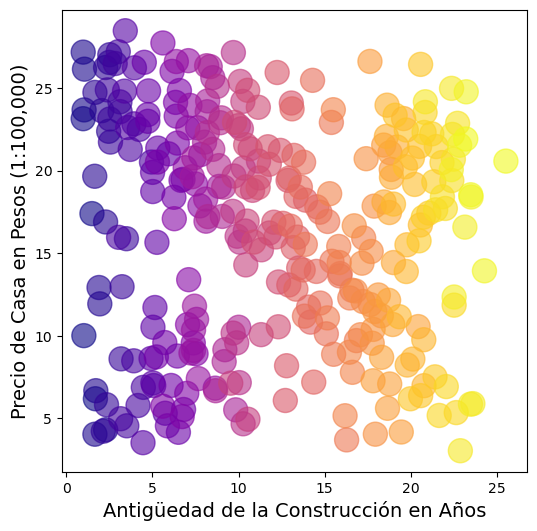

In [9]:
# Graficar datos
plt.figure(figsize=(6, 6))
plt.scatter(x=datos[:, 0], 
            y=datos[:, 1], 
            c=np.linspace(0, 1, datos.shape[0]), 
            s=300, 
            alpha=0.6)
plt.xlabel("Antigüedad de la Construcción en Años", fontsize=14)
plt.ylabel("Precio de Casa en Pesos (1:100,000)", fontsize=14)
plt.box(True)
plt.show()

### Métricas de Distancia entre Vecinos

* `DBSCAN`: detector de cluster no supervisado.

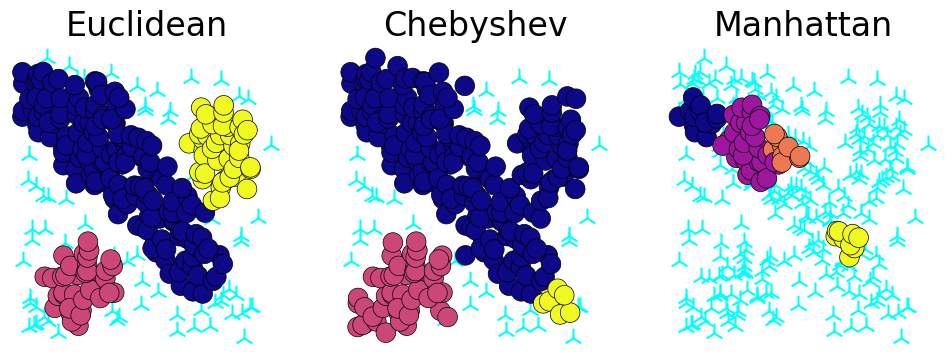

In [11]:
from sklearn.cluster import DBSCAN

# Cargar datos
datos = np.loadtxt("venta_propiedades.csv", delimiter=",")

# Identificar Clusters con diferentes distancias
distancias = ["euclidean", "chebyshev", "manhattan"]

fig = plt.figure(figsize=(12, 4))
plt.set_cmap("plasma")
for d in range(len(distancias)):
    clusters = DBSCAN(2, min_samples=10, 
                      metric=distancias[d]).fit_predict(datos)
    ax = fig.add_subplot(1, 3, d+1)
    # puntos considerados ruido
    ax.scatter(datos[clusters==-1][:, 0], datos[clusters==-1][:, 1], 
               c="cyan", s=200, marker="2")
    # puntos pertenencientes a clusters
    ax.scatter(datos[clusters>=0][:, 0], datos[clusters>=0][:, 1], 
               c=clusters[clusters>=0], s=200, 
               linewidth=0.5, edgecolors="black")
    ax.set_title(distancias[d].capitalize(), fontsize=24)
    ax.axis("off")
    
plt.show()